# Quantum Query Algorithms

## Query Model of Computation

A typical computational model includes three main components: input provided at once, computation or processing, and output. However, the Query Model is different in terms of the way the input is made available. The computing process must query an input function to gain information regarding the input. The input function acts as a blackbox and can be thought of as giving random access to various parts of the whole input. The efficiency of Query algorithms can be determined in simple terms by counting the number of times the computation queries the input function.

In quantum circuits, input functions are represented as unitary gates. The gates receive the query $a$ and an ancilla $b$ in the form $|b\rangle|a\rangle$ and outputs $|b \oplus f(a)\rangle|a\rangle$.

## Deutsch's algorithm

- Objective, given an input function $fx(): \sum \rightarrow \sum$, determine whether it is constant or balanced.
- The function takes one bit as input and outputs one bit.
- For all input combinations, a **constant** function produces the same output.
- For all input combinations, a **balanced** function produces an equal number of 0 and 1.

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

In [3]:
def deutsch_function(case: int):
    # This function generates a quantum circuit for one of the 4 functions
    # from one bit to one bit

    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")

    f = QuantumCircuit(2)
    if case in [2, 3]:
        f.cx(0, 1)
    if case in [3, 4]:
        f.x(1)
    return f

Breakdown of the four cases:

**Case 1: Constant zero function**

|a|f(a)|
|---|---|
|0|0|
|1|0|

Gate output: $|b \oplus 0\rangle|a\rangle$ = $|b\rangle|a\rangle$

**Case 2: Identity function**

|a|f(a)|
|---|---|
|0|0|
|1|1|

Gate output:

if a = 0, $|b \oplus 0\rangle|a\rangle$ = $|b\rangle|a\rangle$

if a = 1, $|b \oplus 1\rangle|a\rangle$ = $| \neg b\rangle|a\rangle$

**Case 3: NOT function**

|a|f(a)|
|---|---|
|0|1|
|1|0|

Gate output:

if a = 0, $|b \oplus 1\rangle|a\rangle$ = $| \neg b\rangle|a\rangle$

if a = 1, $|b \oplus 0\rangle|a\rangle$ = $|b\rangle|a\rangle$

**Case 4: Constant one function**

|a|f(a)|
|---|---|
|0|1|
|1|1|

Gate output: $|b \oplus 1\rangle|a\rangle$ = $| \neg b\rangle|a\rangle$

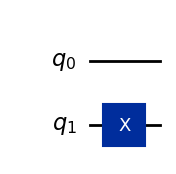

In [20]:
display(deutsch_function(4).draw(output="mpl"))

In [5]:
def compile_circuit(function: QuantumCircuit):
    # Compiles a circuit for use in Deutsch's algorithm.

    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)

    qc.x(n)
    qc.h(range(n + 1))

    qc.barrier()
    qc.compose(function, inplace=True)
    qc.barrier()

    qc.h(range(n))
    qc.measure(range(n), range(n))

    return qc

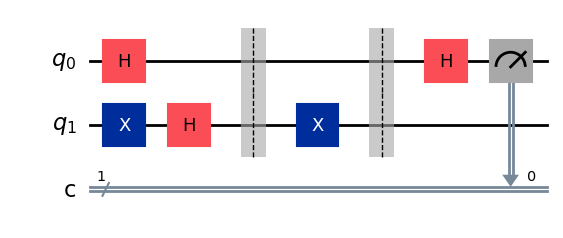

In [26]:
display(compile_circuit(deutsch_function(4)).draw(output="mpl"))

In [27]:
def deutsch_algorithm(function: QuantumCircuit):
    # Determine if a one-bit function is constant or balanced.

    qc = compile_circuit(function)

    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if measurements[0] == "0":
        return "constant"
    return "balanced"

In [28]:
f = deutsch_function(4)
display(deutsch_algorithm(f))

'constant'